In [ ]:

import kagglehub
import pandas as pd
import os

# Download the dataset from KaggleHub
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

# Define the paths to the CSV files
training_csv_path = os.path.join(path, 'twitter_training.csv')
validation_csv_path = os.path.join(path, 'twitter_validation.csv')

# Define column names
column_names = ['tweet_id', 'entity', 'sentiment', 'tweet_text']

# Load the datasets, specifying header=None as the files do not have a header row,
# then assign the column names.
training_df = pd.read_csv(training_csv_path, header=None, names=column_names)
validation_df = pd.read_csv(validation_csv_path, header=None, names=column_names)

print("Training DataFrame head:")
display(training_df.head())
print("\nValidation DataFrame head:")
display(validation_df.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Training DataFrame head:


,tweet_id,entity,sentiment,tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Validation DataFrame head:


,tweet_id,entity,sentiment,tweet_text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [ ]:
import re
import string
from sklearn.preprocessing import LabelEncoder

# Drop rows with missing tweet_text in the training data
# Validation data has no missing text as confirmed in previous analysis
training_df.dropna(subset=['tweet_text'], inplace=True)
print(f"Training_df shape after dropping nulls: {training_df.shape}")

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()  # Lowercase the text
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply preprocessing to tweet_text column for both dataframes
training_df['processed_tweet_text'] = training_df['tweet_text'].apply(preprocess_text)
validation_df['processed_tweet_text'] = validation_df['tweet_text'].apply(preprocess_text)

print("\nOriginal vs. Processed Tweet Text (Training Data sample):")
display(training_df[['tweet_text', 'processed_tweet_text']].head())

# Encode sentiment labels
label_encoder = LabelEncoder()
training_df['sentiment_encoded'] = label_encoder.fit_transform(training_df['sentiment'])
validation_df['sentiment_encoded'] = label_encoder.transform(validation_df['sentiment'])

print("\nSentiment labels and their encoded values:")
for i, sentiment in enumerate(label_encoder.classes_):
    print(f"{sentiment}: {i}")

Training_df shape after dropping nulls: (73996, 4)

Original vs. Processed Tweet Text (Training Data sample):


,tweet_text,processed_tweet_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...



Sentiment labels and their encoded values:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for manageability

# Fit and transform training data, then transform validation data
X_train = tfidf_vectorizer.fit_transform(training_df['processed_tweet_text'])
X_val = tfidf_vectorizer.transform(validation_df['processed_tweet_text'])

# Assign encoded sentiment labels to y_train and y_val
y_train = training_df['sentiment_encoded']
y_val = validation_df['sentiment_encoded']

print(f"Shape of X_train (TF-IDF features for training): {X_train.shape}")
print(f"Shape of X_val (TF-IDF features for validation): {X_val.shape}")
print(f"Shape of y_train (encoded sentiment for training): {y_train.shape}")
print(f"Shape of y_val (encoded sentiment for validation): {y_val.shape}")

Shape of X_train (TF-IDF features for training): (73996, 5000)
Shape of X_val (TF-IDF features for validation): (1000, 5000)
Shape of y_train (encoded sentiment for training): (73996,)
Shape of y_val (encoded sentiment for validation): (1000,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [ ]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:",path)

100%|██████████| 1.99M/1.99M [00:01<00:00, 1.40MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jp797498e/twitter-entity-sentiment-analysis/versions/2


In [ ]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['twitter_validation.csv', 'twitter_training.csv']


In [ ]:
import pandas as pd

training_csv_path = os.path.join(path, 'twitter_training.csv')
validation_csv_path = os.path.join(path, 'twitter_validation.csv')

training_df = pd.read_csv(training_csv_path)
validation_df = pd.read_csv(validation_csv_path)

print("Training DataFrame head:")
print(training_df.head())
print("\nValidation DataFrame head:")
print(validation_df.head())

Training DataFrame head:
   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     

Validation DataFrame head:
   3364   Facebook Irrelevant  \
0   352     Amazon    Neutral   
1  8312  Microsoft   Negative   
2  4371      CS-GO   Negative   
3  4433     Google    Neutral   
4  6273       FIFA   Negative   

  I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his gran

In [ ]:
training_df = pd.read_csv(training_csv_path, header=None)
validation_df = pd.read_csv(validation_csv_path, header=None)

# Assign meaningful column names
column_names = ['tweet_id', 'entity', 'sentiment', 'tweet_text']
training_df.columns = column_names
validation_df.columns = column_names

print("Training DataFrame with new columns:")
print(training_df.head())
print("\nValidation DataFrame with new columns:")
print(validation_df.head())

Training DataFrame with new columns:
   tweet_id       entity sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                          tweet_text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Validation DataFrame with new columns:
   tweet_id     entity   sentiment  \
0      3364   Facebook  Irrelevant   
1       352     Amazon     Neutral   
2      8312  Microsoft    Negative   
3      4371      CS-GO    Negative   
4      4433     Google     Neutral   

                                          tweet_text  
0  I mentioned on Facebook that I was struggling ...  
1  BBC News - Amazon boss

In [ ]:
print("Missing values in Training DataFrame:")
print(training_df.isnull().sum())

print("\nMissing values in Validation DataFrame:")
print(validation_df.isnull().sum())

Missing values in Training DataFrame:
tweet_id        0
entity          0
sentiment       0
tweet_text    686
dtype: int64

Missing values in Validation DataFrame:
tweet_id      0
entity        0
sentiment     0
tweet_text    0
dtype: int64



Sentiment distribution in Training DataFrame:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


/tmp/ipykernel_685/2766360167.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=training_df, x='sentiment', palette='viridis')


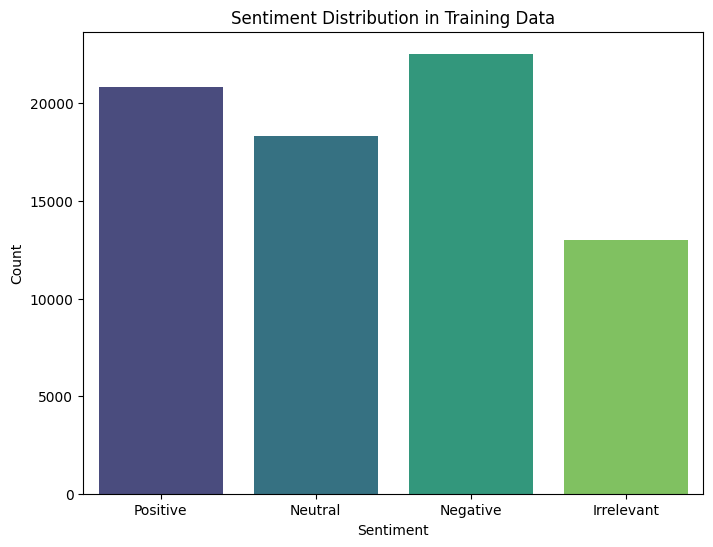

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nSentiment distribution in Training DataFrame:")
print(training_df['sentiment'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=training_df, x='sentiment', palette='viridis')
plt.title('Sentiment Distribution in Training Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
print(f"Original training_df shape: {training_df.shape}")

training_df.dropna(subset=['tweet_text'], inplace=True)

print(f"Training_df shape after dropping nulls: {training_df.shape}")
print("Missing values in Training DataFrame after dropping nulls:")
print(training_df.isnull().sum())

Original training_df shape: (74682, 4)
Training_df shape after dropping nulls: (73996, 4)
Missing values in Training DataFrame after dropping nulls:
tweet_id      0
entity        0
sentiment     0
tweet_text    0
dtype: int64


In [ ]:
# Text Preprocessing Steps
# I will define a function to clean the tweet text
import re
import string

def preprocess_text(text):
    text = text.lower() # Lowercase the text
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# Apply preprocessing to the tweet_text column
training_df['processed_tweet_text'] = training_df['tweet_text'].apply(preprocess_text)
validation_df['processed_tweet_text'] = validation_df['tweet_text'].apply(preprocess_text)

print("\nOriginal vs. Processed Tweet Text (Training Data):")
print(training_df[['tweet_text', 'processed_tweet_text']].head())


Original vs. Processed Tweet Text (Training Data):
                                          tweet_text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                                processed_tweet_text  
0  im getting on borderlands and i will murder yo...  
1  i am coming to the borders and i will kill you...  
2  im getting on borderlands and i will kill you all  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode sentiment labels
label_encoder = LabelEncoder()
training_df['sentiment_encoded'] = label_encoder.fit_transform(training_df['sentiment'])
validation_df['sentiment_encoded'] = label_encoder.transform(validation_df['sentiment'])

print("Sentiment labels and their encoded values:")
for i, sentiment in enumerate(label_encoder.classes_):
    print(f"{sentiment}: {i}")

print("\nTraining DataFrame with encoded sentiment:")
print(training_df[['sentiment', 'sentiment_encoded']].head())

print("\nValidation DataFrame with encoded sentiment:")
print(validation_df[['sentiment', 'sentiment_encoded']].head())

Sentiment labels and their encoded values:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3

Training DataFrame with encoded sentiment:
  sentiment  sentiment_encoded
0  Positive                  3
1  Positive                  3
2  Positive                  3
3  Positive                  3
4  Positive                  3

Validation DataFrame with encoded sentiment:
    sentiment  sentiment_encoded
0  Irrelevant                  0
1     Neutral                  2
2    Negative                  1
3    Negative                  1
4     Neutral                  2


In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

X_train = tfidf_vectorizer.fit_transform(training_df['processed_tweet_text'])
X_val = tfidf_vectorizer.transform(validation_df['processed_tweet_text'])

y_train = training_df['sentiment_encoded']
y_val = validation_df['sentiment_encoded']

print(f"Shape of X_train (TF-IDF features for training): {X_train.shape}")
print(f"Shape of X_val (TF-IDF features for validation): {X_val.shape}")
print(f"Shape of y_train (encoded sentiment for training): {y_train.shape}")
print(f"Shape of y_val (encoded sentiment for validation): {y_val.shape}")

Shape of X_train (TF-IDF features for training): (73996, 5000)
Shape of X_val (TF-IDF features for validation): (1000, 5000)
Shape of y_train (encoded sentiment for training): (73996,)
Shape of y_val (encoded sentiment for validation): (1000,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000



In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode sentiment labels
label_encoder = LabelEncoder()
training_df['sentiment_encoded'] = label_encoder.fit_transform(training_df['sentiment'])
validation_df['sentiment_encoded'] = label_encoder.transform(validation_df['sentiment'])

print("Sentiment labels and their encoded values:")
for i, sentiment in enumerate(label_encoder.classes_):
    print(f"{sentiment}: {i}")

print("\nTraining DataFrame with encoded sentiment:")
print(training_df[['sentiment', 'sentiment_encoded']].head())

print("\nValidation DataFrame with encoded sentiment:")
print(validation_df[['sentiment', 'sentiment_encoded']].head())

Sentiment labels and their encoded values:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3

Training DataFrame with encoded sentiment:
  sentiment  sentiment_encoded
0  Positive                  3
1  Positive                  3
2  Positive                  3
3  Positive                  3
4  Positive                  3

Validation DataFrame with encoded sentiment:
    sentiment  sentiment_encoded
0  Irrelevant                  0
1     Neutral                  2
2    Negative                  1
3    Negative                  1
4     Neutral                  2


In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

X_train = tfidf_vectorizer.fit_transform(training_df['processed_tweet_text'])
X_val = tfidf_vectorizer.transform(validation_df['processed_tweet_text'])

y_train = training_df['sentiment_encoded']
y_val = validation_df['sentiment_encoded']

print(f"Shape of X_train (TF-IDF features for training): {X_train.shape}")
print(f"Shape of X_val (TF-IDF features for validation): {X_val.shape}")
print(f"Shape of y_train (encoded sentiment for training): {y_train.shape}")
print(f"Shape of y_val (encoded sentiment for validation): {y_val.shape}")

Shape of X_train (TF-IDF features for training): (73996, 5000)
Shape of X_val (TF-IDF features for validation): (1000, 5000)
Shape of y_train (encoded sentiment for training): (73996,)
Shape of y_val (encoded sentiment for validation): (1000,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
# Increasing max_iter for better convergence, and setting random_state for reproducibility
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_val)

print("Logistic Regression Model Performance on Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
# The target_names argument helps in displaying sentiment labels instead of encoded integers
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

Logistic Regression Model Performance on Validation Set:
Accuracy: 0.8120

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.80      0.74      0.77       172
    Negative       0.77      0.89      0.82       266
     Neutral       0.88      0.74      0.80       285
    Positive       0.81      0.86      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000

